# Машинное обучение, ФКН ВШЭ

## Практическое домашнее задание 3.1 Базовая генерация признаков

### **Сетап**

Целевая метрика:

$$ \text{Gini} = 2 \cdot \text{ROC-AUC} - 1$$

In [1]:
from sklearn.metrics import roc_auc_score


def gini(y_true, y_score):
    return 2 * roc_auc_score(y_true, y_score) - 1.0

#### **Данные**

На Kaggle лежит датасет по Dota 2, скачанный через OpenDota API и анонимизированный.

Нас интересует исход матча — победа или поражение, исходя из совершенно разных факторов. Это информация о сессии, игроках, героях, и т д. **в первые 15 минут** после начала матча.

Краткая сводка об игре:

- Dota 2 — командная игра: 5 игроков за Свет (Radiant) против 5 за Тьму (Dire).
- Каждый игрок управляет уникальным героем со своим набором атрибутов и способностей.
- Цель — снести главную постройку на вражеской базе (в простонародье трон).
- В процессе матча игроки добывают золото и опыт, покупают предметы и убивают противников, чтобы стать сильнее.
- Ничьих не бывает, фиксированного таймера нет — матч длится до падения трона.

### **Часть 1.**

#### **Задание 1.1. Датасет** (0.5 балла)

Чтобы начать работу с данными, эти данные сперва нужно [загрузить](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105). Пока что нам потребуются лишь:

1. Информация о матчах - `matches_df_train.csv`.
2. Тестовые данные для соревнования - `matches_df_test.csv`.

Посмотрите на все csv-файлы выше, создайте под каждый из них отдельный датафрейм и отметьте (текстом или кодом):
- объемы таблиц: как в Мб, так и `df.shape`
- какие в них есть колонки по своему содержанию

In [2]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

matches_df_train = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/matches_df_train.csv')
matches_df_test = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/matches_df_test.csv')



print("трейн", matches_df_train.memory_usage(deep=True).sum()/(1024*1024), "мб", matches_df_train.shape)
print("тест", matches_df_test.memory_usage(deep=True).sum()/(1024*1024), "мб", matches_df_test.shape)


трейн 92.50748825073242 мб (641090, 7)
тест 8.0858793258667 мб (59748, 5)


In [3]:
matches_df_train.sample(5)

,match_id,date,region,game_mode,duration,radiant_win,avg_mmr
156856,187670,2024-02-21,Middle East,1,2410,True,NaN
400269,479092,2024-09-08,Europe West,1,2775,True,NaN
378511,453061,2024-10-14,South America,3,299,False,6089.8
493510,591057,2024-02-24,South Africa,1,3769,True,3929.2
308362,369113,2024-10-31,Europe West,1,1950,True,3385.9


In [4]:
matches_df_test.sample(5)

,match_id,date,region,game_mode,avg_mmr
43887,564711,2024-12-12,Europe West,22,NaN
12293,159397,2024-12-08,South America,1,NaN
49090,630816,2024-12-02,South America,22,NaN
30874,398811,2024-12-12,Europe West,22,2030.9
56013,719875,2024-12-08,Europe East,1,3580.2


Скопирую описание переменных этих данных из описания датасета:
1) matches_df_train.csv - тренировочные данные матчей:

* match_id - айди матча (деанонимизирован, можете даже не пытаться)
* date - дата, когда был сыгран матч
* region - регион, где был проведен матч
* game_mode - режим матча, в игре их доступно несколько
* duration - длительность матча
* radiant_win - победа команды сил Света и наша целевая переменная
2) matches_df_test.csv - тестовые данные матчей:

* match_id - айди матча (деанонимизирован, можете даже не пытаться)
* date - дата, когда был сыгран матч
* region - регион, где был проведен матч
* game_mode - режим матча, в игре их доступно несколько

И, получается, тут еще есть средний ММР игроков для матча (при этом есть пропуски)

Отдельно хочется посмотреть распределение целевой переменной

radiant_win
True     327451
False    313639
Name: count, dtype: int64


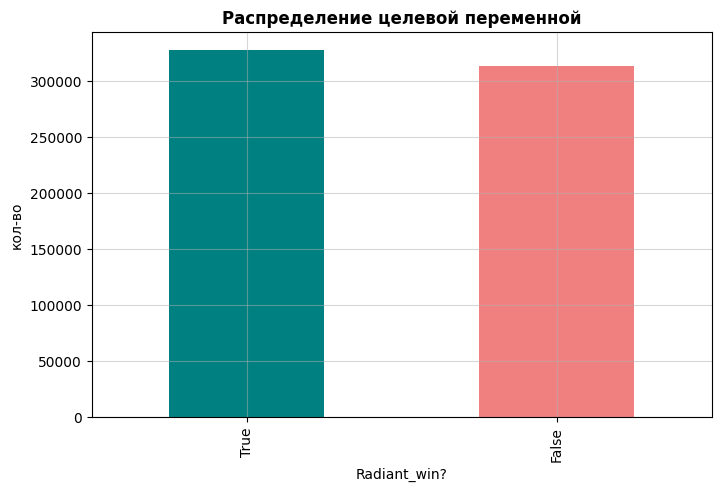

In [5]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

target = "radiant_win"


print(matches_df_train[target].value_counts())

fig, ax = plt.subplots(figsize=(8, 5))

matches_df_train[target].value_counts().plot( kind='bar', ax=ax, color=['teal', 'lightcoral'])
ax.set_title("Распределение целевой переменной", fontweight='bold')
ax.set_xlabel("Radiant_win?")
ax.set_ylabel("кол-во")
ax.grid(alpha = 0.5)

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** подходящая ли в данном случае метрика $\text{Gini}$ в сравнении, например, с $\text{AUC-PR}$?

**Ответ:**
Да, подходящая, так как доли двух классов примерно равны, а AUC-PR скорее необходим, когда одного класса сильно больше другого.
</div> 

#### **Задание 1.2. Категории** (0.75 балла)


В целом, данные уже содержат признаки, по которым что-то даже можно построить, в частности — регионы.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

У Radiant, по сравнению с Dire, исторически есть небольшое преимущество — чуть удобнее карта, порядок выбора героев и всё такое. В разных регионах бывают разные предпочтения по стилям игры и тактикам, и где-то это преимущество реализуют лучше

</div>

Посмотрите, где у нас содержится информация о регионе, на серверах которого был проведён матч, и постройте 2 графика:
1) Распределение регионов (процентное и абсолютное) на тренировочных и тестовых данных
2) Среднее значение таргета на трейне, в зависимости от региона

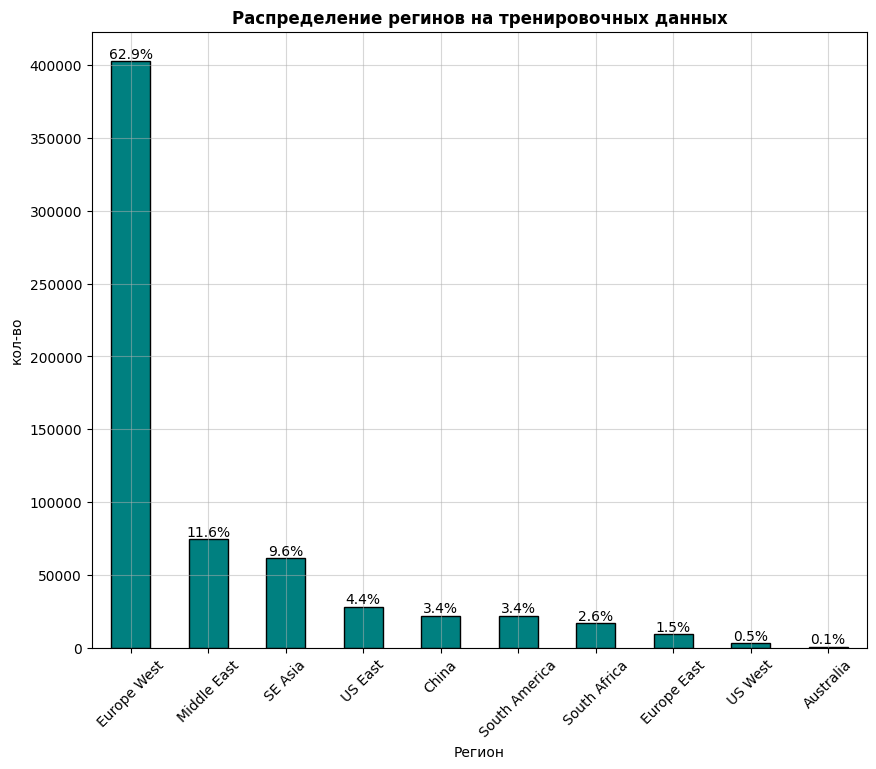

In [6]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )


fig, ax = plt.subplots(figsize=(10, 8))

total_train = matches_df_train.shape[0]

matches_df_train['region'].value_counts().plot(kind='bar', ax=ax, edgecolor='black', color='teal')
ax.set_title("Распределение регинов на тренировочных данных", fontweight='bold')
ax.set_xlabel("Регион")
ax.set_ylabel("кол-во")
ax.grid(alpha = 0.5)
ax.tick_params(axis='x', rotation=45)

values = ax.containers[0].datavalues
labels = [f'{v/total_train*100:.1f}%' for v in values]
ax.bar_label(ax.containers[0], labels=labels)

plt.show()

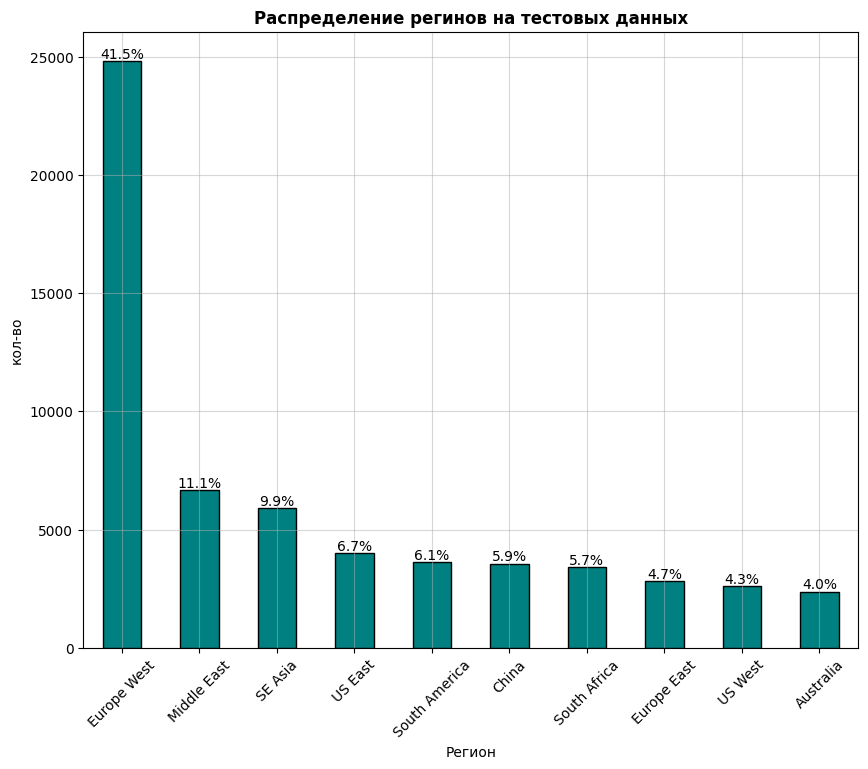

In [7]:
fig, ax = plt.subplots(figsize=(10, 8))

total_test = matches_df_test.shape[0]

matches_df_test['region'].value_counts().plot(kind='bar', ax=ax, edgecolor='black', color='teal')
ax.set_title("Распределение регинов на тестовых данных", fontweight='bold')
ax.set_xlabel("Регион")
ax.set_ylabel("кол-во")
ax.grid(alpha = 0.5)
ax.tick_params(axis='x', rotation=45)

values = ax.containers[0].datavalues
labels = [f'{v/total_test*100:.1f}%' for v in values]
ax.bar_label(ax.containers[0], labels=labels)

plt.show()

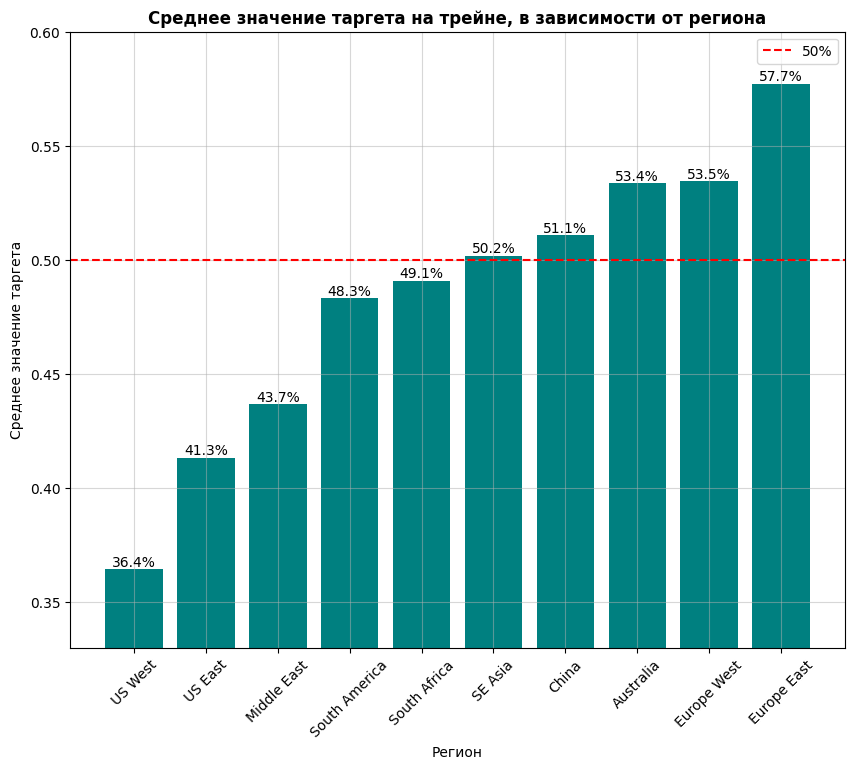

In [8]:
fig, ax = plt.subplots(figsize=(10, 8))

region_target_mean = matches_df_train.groupby('region')[target].mean().sort_values()

ax.bar(region_target_mean.index, region_target_mean.values, color='teal')

ax.set_title("Среднее значение таргета на трейне, в зависимости от региона", fontweight='bold')
ax.set_xlabel("Регион")
ax.set_ylabel("Среднее значение таргета")
ax.grid(alpha = 0.5)
ax.tick_params(axis='x', rotation=45)
ax.set_ylim(0.33, 0.6)

values = ax.containers[0].datavalues
labels = [f'{v*100:.1f}%' for v in values]
ax.bar_label(ax.containers[0], labels=labels)


ax.axhline(y=0.5, color='red', linestyle='--', label='50%')
ax.legend()

plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы можете сказать о распределении регионов? Объясните, получится ли вообще обучить по нему модель, есть ли там сигнал?

**Ответ:**  
Распределение регионов очень неравномерное (особенно плохи дела как раз на трейне). Европы больше 60%, а Австарилии меньше 0.1%. А вот в тесте, например, австралии достаточно. С другой стороны, для австралии распределение близко к 50%, поэтому, кажется, что это не сильная проблема. А вот с US west дела как будто хуже. На малом количестве данных мы имеем сильный перекос в сторону сил тьмы, наверное стоит быть повнимательнее с этим далее.
</div>

Наша первая развилка — <font color="#cb9255">**выбор**</font>, какой из энкодеров стащить. Рекомендуется брать что-то из `category_encoders`, они похожи на стандартные из `sklearn`, но их больше и применять их проще.

| <font color="#cb9255">**One-Hot Encoder**</font> | <font color="#cb9255">**Target Encoder**</font> |
| :--- | :--- |
| Превращает категориальный признак в вектор из 0 и 1.  <br> 1 стоит на месте i‑го индекса, если у объекта есть i‑е значение признака. | Кодирует категориальный признак средним значением таргета.  <br> Среднее считается по всем объектам с i‑м значением признака. |

Можно взять и другой, но морально готовьтесь получить $\text{Gini} = 0$
</div>

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Без энкодинга использовать категориальные признаки в линейных моделях, увы, нельзя, выбор без выбора 

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** какой из энкодеров кажется вам наиболее привлекательным? Почему?

**Ответ:**
Выберу one hot, так как интересно посмотреть на сочетания признака региона с другими возможными признаками и как будто так у нас сохранится больше инфы о матчах. Кроме того, кажется, что таргет стоило бы использовать, если бы у нас "вклад" всех регионов был одинаковым. Но вполне может быть такое, что, например, для китайцев сильнее на ответ влияет другой признак, а для европейцев влияет именно сторона. но если у них одинаковый средний таргет, то мы дадим им одинаковый вес, хотя логично, что это не совсем правильно.

Особенно, если я например захочу создать признак: "регион"*"длительность матча"
</div>

Закодируйте колонку `region` выбранным вами способом

In [10]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

import category_encoders as ce

mathes_df_res_train = matches_df_train[target]
matches_df_train = matches_df_train.drop(['duration', target], axis = 1)

encoder = ce.OneHotEncoder(cols=['region'], use_cat_names=True)
matches_df_train_enc = encoder.fit_transform(matches_df_train)
matches_df_test_enc = encoder.transform(matches_df_test)

matches_df_train_enc[target] = mathes_df_res_train.values

In [11]:
matches_df_train_enc.head(3)

,match_id,date,region_Europe West,region_South Africa,region_SE Asia,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,region_Australia,game_mode,avg_mmr,radiant_win
0,1,2024-02-12,1,0,0,0,0,0,0,0,0,0,4,3519.7,False
1,2,2024-04-08,0,1,0,0,0,0,0,0,0,0,2,2330.9,True
2,3,2024-06-16,0,0,1,0,0,0,0,0,0,0,1,1579.6,True


In [12]:
print('чтобы не было дамми треп и мультиколлинеарности, дропнем одну колонку')

matches_df_train_enc = matches_df_train_enc.drop('region_SE Asia', axis = 1)
matches_df_test_enc = matches_df_test_enc.drop('region_SE Asia', axis = 1)

чтобы не было дамми треп и мультиколлинеарности, дропнем одну колонку


In [13]:
matches_df_train_enc.head(3)

,match_id,date,region_Europe West,region_South Africa,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,region_Australia,game_mode,avg_mmr,radiant_win
0,1,2024-02-12,1,0,0,0,0,0,0,0,0,4,3519.7,False
1,2,2024-04-08,0,1,0,0,0,0,0,0,0,2,2330.9,True
2,3,2024-06-16,0,0,0,0,0,0,0,0,0,1,1579.6,True


#### **Задание 1.3. Даты** (1.25 балла)

Если нам хочется видеть будущее, именно время диктует, что брать можно, а что никак нельзя

Найдите колонку дат на тренировочных данных и:
1. Постройте график доли побед Radiant в зависимости от даты матча
2. Сравните временные диапазоны на трейне и тесте

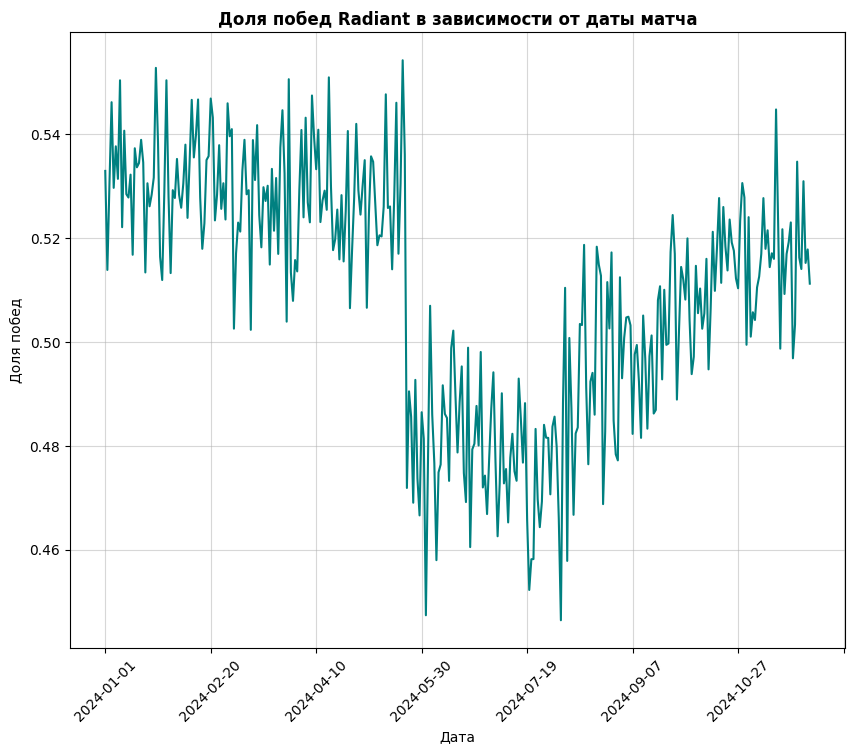

In [14]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

fig, ax = plt.subplots(figsize=(10, 8))

date_res = matches_df_train_enc.groupby('date')[target].mean()

date_res.plot(kind='line', ax=ax, color='teal')
ax.set_title("Доля побед Radiant в зависимости от даты матча", fontweight='bold')
ax.set_xlabel("Дата")
ax.set_ylabel("Доля побед")
ax.grid(alpha = 0.5)
ax.tick_params(axis='x', rotation=45)

plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** видите ли вы какой-то паттерн в распределении дат? Можете ли вы объяснить при помощи сети Интернет, что там произошло? \
(Подсказка: соревновательные игры периодически обновляются)

**Ответ:**

В мае 2024 вышла обнова, в которой добвили новые механики: https://dota2.ru/updates/42569-v-dota-2-vysel-globalnyj-patc-7-36-dobavleny-dve-novye-mehaniki-vrozdennye-sposobnosti-i-aspekty/?ysclid=mmdrwn94vu738386979

"В ночь на 23 мая Valve выпустила глобальное обновление 7.36. Разработчики Dota 2 добавили героям врождённые способности и аспекты, а также переработали укрепление построек и значительно изменили баланс героев. 
Это обновление вводит две механики, касающиеся каждого героя: врождённые способности и аспекты."

</div>

Теперь давайте что-нибудь повыделяем.

<div style="border-left: 5px solid #5584a8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Даты сами по себе это всегда очень простые фичи, функционал есть в любой библиотеке. Связь с таргетом может быть, но не обязана. Именно даты проверить легко и быстро, зависимости бывают неожиданными. Впрочем, это не единственная причина, не переключайтесь

</div>

С таймстемпом можно делать не так много, кроме базовых манипуляций:

1. Вытащите лежащую на поверхности информацию, например, день и день недели. Хватит и этих двух
2. Посмотрите сами на список возможных признаков, будь то [pandas](https://pandas.pydata.org/docs/user_guide/timeseries.html#time-date-components) или [polars](https://docs.pola.rs/api/python/stable/reference/expressions/temporal.html), и <font color="#cb9255">**либо добавьте**</font> 2 признака, которые, как вам кажется, сработают, <font color="#cb9255">**либо поясните**</font>, почему это ничего не даст

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** необходимо ли кодировать признаки из дат? Если да, то какие и как? Если нет, то почему? </font>

**Ответ:** 
* Закодируем день(от 1 до 30), вдруг найдем связь(например 15 числа зп выплачивают))))
* Закодируем день недели, мб в выходные и в будни контингент игроков отличается
* Ну и разумеется, закодируем каникулы россйских школьников, потому что эти киберкотлеты могут делать что угодно....

В целом попробуем закадируем, так как вдруг действительно можно найти какую-то связь. Мне кажется, что контингент игроков в разные дни может быть разный
</div>

3. Закодируйте новые признаки, согласно вашему ответу

In [15]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
matches_df_train_enc['date'] = pd.to_datetime(matches_df_train_enc['date'])
matches_df_test_enc['date'] = pd.to_datetime(matches_df_test_enc['date'])

matches_df_train_enc['day_1_30'] = matches_df_train_enc['date'].dt.day
matches_df_test_enc['day_1_30'] = matches_df_test_enc['date'].dt.day
matches_df_train_enc['weekday'] = matches_df_train_enc['date'].dt.weekday
matches_df_test_enc['weekday'] = matches_df_test_enc['date'].dt.weekday


def is_russian_school_holiday(date):
    month = date.month
    day = date.day
    
    if month in [6, 7, 8]:
        return 1
    
    if month == 10 and day >= 25:
        return 1
    if month == 11 and day <= 7:
        return 1
    
    if month == 3 and day >= 23:
        return 1
    if month == 4 and day <= 5:
        return 1

    if month == 5 and 1 <= day <= 10:
        return 1
    
    if month == 12 and day >= 27:
        return 1
    if month == 1 and day <= 10:
        return 1

    return 0

matches_df_train_enc['russian_holidays'] = matches_df_train_enc['date'].apply(is_russian_school_holiday)
matches_df_test_enc['russian_holidays'] = matches_df_test_enc['date'].apply(is_russian_school_holiday)

mathes_df_res_train = matches_df_train_enc[target]
matches_df_train_enc = matches_df_train_enc.drop(target, axis = 1)

encoder1 = ce.OneHotEncoder(cols=['day_1_30'], use_cat_names=True)
matches_df_train_enc1 = encoder1.fit_transform(matches_df_train_enc)
matches_df_test_enc1 = encoder1.transform(matches_df_test_enc)

encoder2 = ce.OneHotEncoder(cols=['weekday'], use_cat_names=True)
matches_df_train_enc1 = encoder2.fit_transform(matches_df_train_enc1)
matches_df_test_enc1 = encoder2.transform(matches_df_test_enc1)

# каникулы школьников итак уже бинарны

matches_df_train_enc1[target] = mathes_df_res_train.values

In [16]:
#чтобы не было дамми треп
matches_df_train_enc1 = matches_df_train_enc1.drop(['weekday_0.0', 'day_1_30_30.0'], axis = 1)
matches_df_test_enc1 = matches_df_test_enc1.drop(['weekday_0.0', 'day_1_30_30.0'], axis = 1)

In [17]:
matches_df_train_enc1.head(3)

,match_id,date,region_Europe West,region_South Africa,region_Middle East,region_US East,region_Europe East,region_South America,region_China,region_US West,...,day_1_30_15.0,day_1_30_2.0,weekday_6.0,weekday_1.0,weekday_5.0,weekday_3.0,weekday_2.0,weekday_4.0,russian_holidays,radiant_win
0,1,2024-02-12,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,False
1,2,2024-04-08,0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,True
2,3,2024-06-16,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,1,True


Кажется, мы что-то забыли... Ах да, надо бы и модель обучить, вот только без валидации это будет как-то не по-моповски, надо озаботиться этим вопросом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

На самом деле временная структура нужна не столь, чтобы вытащить какие-то признаки, сколько, чтобы понять распределение и изменение данных во времени же. Даты играют в этом прямую роль

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** почему здесь будет не лучшим решением брать случайное разбиение на трейн и валидацию?

**Ответ:**
Так как у нас данные меняются со временем, то если брать случайное разбиение, то в трейне будует инфа о как бы будущих данных. Хотя в реальности у нас в тесте данные за декабрь, а в трейне только до ноября. И как бы мы не знаем, что было в будущем. Такое же надо "повторить" и на валидации.

</div>

Тут выбор у вас решили отобрать, делать мы будем OOT валидацию. Впрочем, какие-то опции ещё остались

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">OOT (Out-of-Time)</font>
    </th>
    <th width="50%">
      <font color="#cb9255">CV OOT (Cross-Validation Out-of-Time)</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Валидация с одной отложенной подвыборкой, <br>
      взятой после трешхолда t. Простая, как палка, <br>
      но если валидация получится грустной — <br>
      аномальной, нетипичной, маленькой, — <br>
      то и метрика ваша тоже будет грустной.
    </td>
    <td valign="top">
      Кросс-валидация с k разбиениями по времени <br>
      с итеративным расширением исходного фолда. <br>
      Оценка метрики сместится куда меньше <br>
      по сравнению с плохим сплитом OOT, <br>
      но это долго, если фолдов много.
    </td>
  </tr>
  <tr>
    <td valign="top">
      <code>sklearn.model_selection.train_test_split</code>
    </td>
    <td valign="top">
      <code>sklearn.model_selection.TimeSeriesSplit</code>
    </td>
  </tr>
</table>



Настройте любой из видов валидации (<font color="#cb9255">**трешхолд**</font> `t` или <font color="#cb9255">**число фолдов**</font> <code>n_folds</code></font> подберите сами). Они оба должны показывать качество адекватно, хотя второй теоретически должен быть более обоснован. CV-OOT не даст вам бонусов, но кто знает, за какие крохи Джини придётся бороться на соревновании?

In [18]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

from sklearn.model_selection import TimeSeriesSplit


matches_df_train_enc1 = matches_df_train_enc1.sort_values('date')

tscv = TimeSeriesSplit(n_splits=5)

И вот теперь мы уже наконец-то будем что-то обучать. Моделей классификации мы знаем как минимум две — SVM и логистическую регрессию, но есть нюанс.

Выборы, выборы..:

<table width="800" border="1" cellpadding="8" cellspacing="0">
  <tr>
    <th width="50%">
      <font color="#cb9255">Dedicated model</font>
    </th>
    <th width="50%">
      <font color="#cb9255">Gradient Descent</font>
    </th>
  </tr>
  <tr>
    <td valign="top">
      Большой разницы между <code>LogisticRegression</code> и <code>LinearSVC</code> <br>
      из <code>sklearn.linear_model</code> на самом деле нет: <br>
      разделяющие поверхности очень похожи, <br>
      оба хорошо оптимизированы специальными солверами.
    </td>
    <td valign="top">
      Градиентный спуск через <code>sklearn.linear_model.SGDClassifier</code> <br>
      с параметрами <code>loss="log_loss"</code> или <code>loss="hinge"</code> — <br>
      очень соблазнительная альтернатива, но!
    </td>
  </tr>
  <tr>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Обучать и применять их в разы проще, <br>
      фит–предикт делает брр. <br>
      <font color="#cb9255"><b>−</b></font> Они используют сразу всю выборку <br>
      для обучения, а в ходе задания наша выборка <br>
      может вырасти раз так в 1000, немало!
    </td>
    <td valign="top">
      <font color="#cb9255"><b>+</b></font> Влезет любой датасет. <br>
      <font color="#cb9255"><b>+</b></font> Бóльший контроль над процессом обучения. <br>
      <font color="#cb9255"><b>−</b></font> Обучать на больших данных <br>
      (скорее про часть <b>advanced</b>) придётся через <code>partial_fit</code>, неудобно. <br>
      <font color="#cb9255"><b>−</b></font> Нужно подбирать больше гиперпараметров.
    </td>
  </tr>
</table>


Выберите <font color="#cb9255">**одну из**</font> моделей выше (хотя `LinearRegression` <font color="#cb9255">**тоже можно**</font>, если у вас сегодня авантюрное настроение, успех не гарантирован, о рисках узнаете на лекции) **(обращаем внимание, что другие варианты запрещены)**. Обучите по одному экземпляру на группах признаков:

- дат
- регионов
- дат и регионов

Ну и замерьте качество!

<font color="#cb9255">**NB**</font>: 

1. Вы сразу можете строить роскошный пайплайн обучения, а не делать по кускам в отдельных блоках, про это есть **advanced** пункт (**6.1**) на 0.5 баллов
2. Если у вас есть GPU, то почему бы его и не [использовать](https://docs.rapids.ai/api/cuml/stable/)? Если гпу у вас нет, у вас теперь точно есть Kaggle, который щедро дарит 30 часов гпу в неделю, пользуйтесь на здоровье, за это есть маленький, но приятный буст на 0.25 балла (**пункт 6.3**)
3. Наконец, если вы сразу оформите хранилище для результатов запусков ваших моделей, вы снова получите 0.25 балла (**пункт 6.2**)

In [19]:
matches_df_train_enc1.columns

Index(['match_id', 'date', 'region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'game_mode', 'avg_mmr', 'day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays',
       'radiant_win'],
      dtype='object')

In [20]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X = matches_df_train_enc1.drop(target, axis=1)
y = matches_df_train_enc1[target]
X_date = X[['day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays']]

cv_results = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_date)):
    print(f"ФОЛД {fold + 1}")
    
    X_train, X_val = X_date.iloc[train_idx], X_date.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted')
    recall = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_pred_proba)


    cv_results['fold'].append(fold + 1)
    cv_results['accuracy'].append(accuracy)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1'].append(f1)
    cv_results['roc_auc'].append(roc_auc)
    
print("результаты только даты:")

results_df = pd.DataFrame(cv_results)
print(results_df.round(4))

print(f"\nСредние значения:")
print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}")
print(f"  Precision: {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
print(f"  F1-score:  {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}")
print(f"  ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}")

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты только даты:
   fold  accuracy  precision  recall      f1  roc_auc
0     1    0.4958     0.5032  0.4958  0.4915   0.5011
1     2    0.4968     0.4972  0.4968  0.4968   0.5020
2     3    0.5127     0.5041  0.5127  0.4839   0.5025
3     4    0.5027     0.5031  0.5027  0.4938   0.5036
4     5    0.5074     0.5021  0.5074  0.4882   0.5012

Средние значения:
  Accuracy:  0.5031 +/- 0.0064
  Precision: 0.5019 +/- 0.0025
  Recall:    0.5031 +/- 0.0064
  F1-score:  0.4908 +/- 0.0044
  ROC-AUC:   0.5021 +/- 0.0009


In [21]:

X_reg = X[['region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia']]

cv_results = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_reg)):
    print(f"ФОЛД {fold + 1}")
    
    X_train, X_val = X_reg.iloc[train_idx], X_reg.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted')
    recall = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_pred_proba)


    cv_results['fold'].append(fold + 1)
    cv_results['accuracy'].append(accuracy)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1'].append(f1)
    cv_results['roc_auc'].append(roc_auc)
    
print("результаты только регионы:")

results_df = pd.DataFrame(cv_results)
print(results_df.round(4))

print(f"\nСредние значения:")
print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}")
print(f"  Precision: {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
print(f"  F1-score:  {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}")
print(f"  ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}")

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты только регионы:
   fold  accuracy  precision  recall      f1  roc_auc
0     1    0.5384     0.5340  0.5384  0.5291   0.5355
1     2    0.5342     0.5339  0.5342  0.5244   0.5374
2     3    0.5246     0.5383  0.5246  0.5097   0.5384
3     4    0.5341     0.5393  0.5341  0.5191   0.5403
4     5    0.5357     0.5346  0.5357  0.5207   0.5368

Средние значения:
  Accuracy:  0.5334 +/- 0.0047
  Precision: 0.5360 +/- 0.0023
  Recall:    0.5334 +/- 0.0047
  F1-score:  0.5206 +/- 0.0064
  ROC-AUC:   0.5377 +/- 0.0016


In [22]:
X_date_reg = X[['region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays']]

cv_results = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_date_reg)):
    print(f"ФОЛД {fold + 1}")
    
    X_train, X_val = X_date_reg.iloc[train_idx], X_date_reg.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted')
    recall = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_pred_proba)


    cv_results['fold'].append(fold + 1)
    cv_results['accuracy'].append(accuracy)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1'].append(f1)
    cv_results['roc_auc'].append(roc_auc)
    
print("результаты вместе даты + регионы:")

results_df = pd.DataFrame(cv_results)
print(results_df.round(4))

print(f"\nСредние значения:")
print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}")
print(f"  Precision: {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
print(f"  F1-score:  {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}")
print(f"  ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}")

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты вместе даты + регионы:
   fold  accuracy  precision  recall      f1  roc_auc
0     1    0.5400     0.5352  0.5400  0.5265   0.5351
1     2    0.5341     0.5341  0.5341  0.5217   0.5384
2     3    0.5252     0.5353  0.5252  0.5160   0.5396
3     4    0.5310     0.5344  0.5310  0.5204   0.5395
4     5    0.5359     0.5352  0.5359  0.5177   0.5369

Средние значения:
  Accuracy:  0.5333 +/- 0.0049
  Precision: 0.5348 +/- 0.0005
  Recall:    0.5333 +/- 0.0049
  F1-score:  0.5205 +/- 0.0036
  ROC-AUC:   0.5379 +/- 0.0017


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** помогли ли даты? А должны? Хотите ли вы их оставить?

**Ответ:**
На самом деле разница почти незначительна(с датами или без дат) и рокаук одинаковый. Но хочется протащить эту фичу, поэтому оставил её)) Ну и пока она работает, на 0.02 вырос рокаук, когда мы к фичам про страны добавили фичи про даты.

Оставлю эти фичи с датами, интересно понаблюдать дальше. ВЕДЬ ШКОЛЬНИКИ СНГ В ДОТЕ ЭТО СИЛА.

Потом, если что, когда будет борьба за лидерборд или долгие вычисления, то удалим ее.
</div>

#### **Задание 1.4. Числа** (0.75 балла)

Остался неотвеченным лишь один вопрос — а что числовые признаки? С ними всё одновременно и проще, и сложнее.

Найдите, где хранится средний ммр матча — это средний рейтинг игроков, которые в нём участвовали, чем выше, тем лучше.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

От ммра напрямую зависит то, как игроки пользуются естественным преимуществом Radiant. Чем игроки сильнее, тем чаще это должно происходить, в теории

</div>

Сделайте (на трейне, валидации и тесте) вот что :
1. Постройте график распределения ммров
2. Сравните, насколько распределения похожи между собой визуально

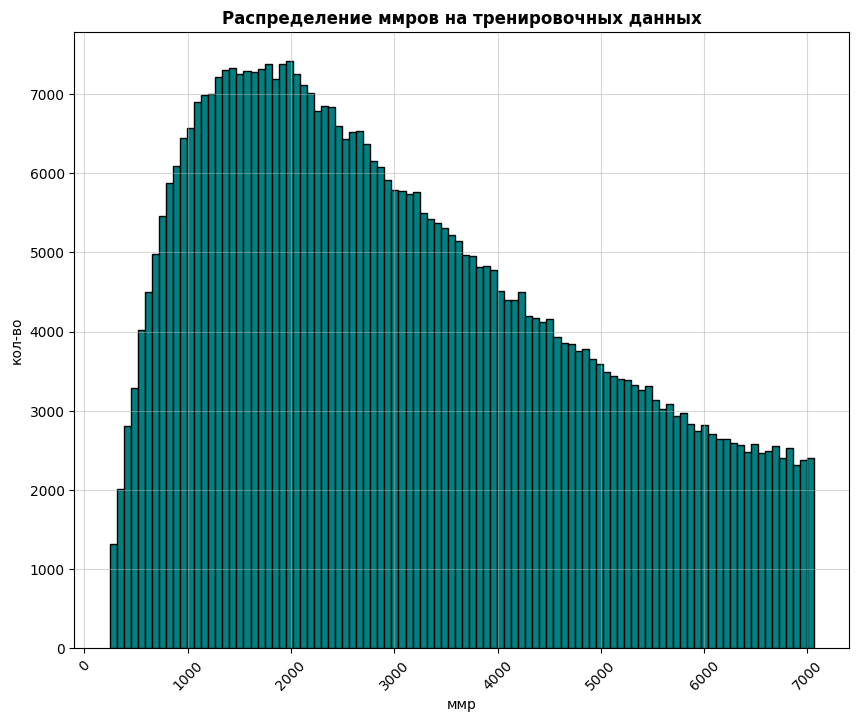

In [23]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
# про валидацию непон, у нас же кроссвалидацию из данных исходного трейна

fig, ax = plt.subplots(figsize=(10, 8))
ax.hist(matches_df_train_enc1['avg_mmr'], bins = 100, edgecolor='black', color='teal')

ax.set_title("Распределение ммров на тренировочных данных", fontweight='bold')
ax.set_xlabel("ммр")
ax.set_ylabel("кол-во")
ax.grid(alpha = 0.5)
ax.tick_params(axis='x', rotation=45)



plt.show()

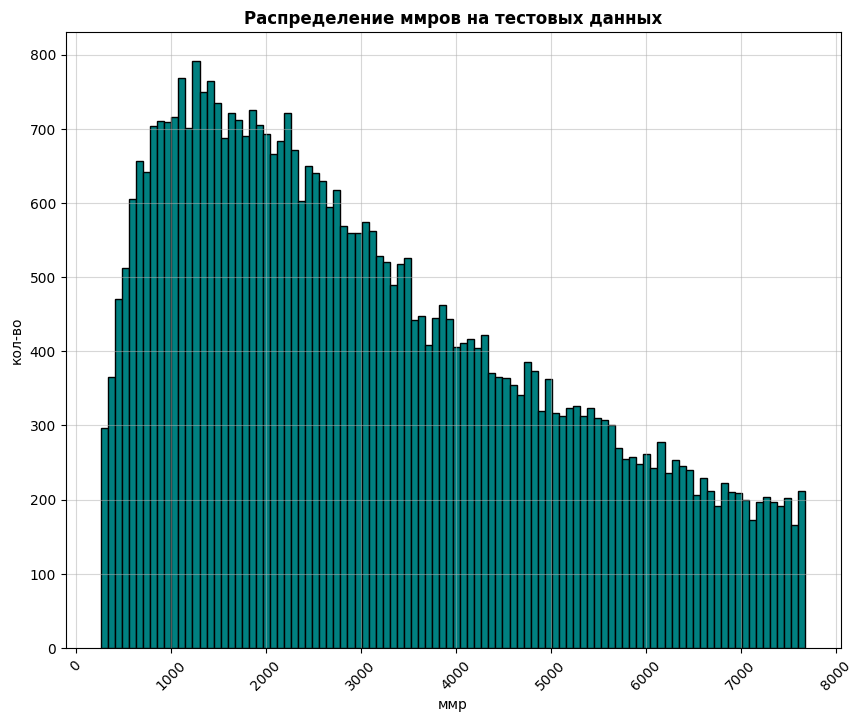

In [24]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.hist(matches_df_test_enc1['avg_mmr'], bins = 100, edgecolor='black', color='teal')

ax.set_title("Распределение ммров на тестовых данных", fontweight='bold')
ax.set_xlabel("ммр")
ax.set_ylabel("кол-во")
ax.grid(alpha = 0.5)
ax.tick_params(axis='x', rotation=45)



plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** как бы вы описали это распределение в целом, похоже ли оно на что-то знакомое вам? 

**Ответ:**
Распределения похожи, что логично.

Я не знаю, это отчасти похоже и на биномиальное распределение, и на парето, и на нормальное с тяжелым хвостом.
</div>

Кто-то где-то говорил, что числовые признаки надо бы стандартизировать, чтобы вышло что-то годное. Этот кто-то прав, но как известно, практика — критерий истины

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Но в действительности это зависит от данных. Сходимость итеративных алгоритмов улучшается, но может пострадать качество, особенно, если распределение не нормальное, или есть отличие в $\mu$ и $\sigma$ на тесте
 
Однако даже пара пунктов Джини это довольно хороший буст, вы убедитесь, когда приступите к сореве, за них нужно бороться любой ценой, тем более, что это почти бесплатно

</div>

Так или иначе, у нас и распределение то не нормальное, но, к счастью, это решаемо. Сделайте такие преобразования признака ммров $f_{\text{mmr}}$ и нарисуйте их график:

$$f_{\text{mmr}} \mapsto \log( 1+f_{\text{mmr}} ); \qquad f_{\text{mmr}} \mapsto \sqrt{f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \frac{1}{1+f_{\text{mmr}}}; \qquad f_{\text{mmr}} \mapsto \exp{\log f_{\text{mmr}}};$$

Затем выберите то, что вам нравится больше всего

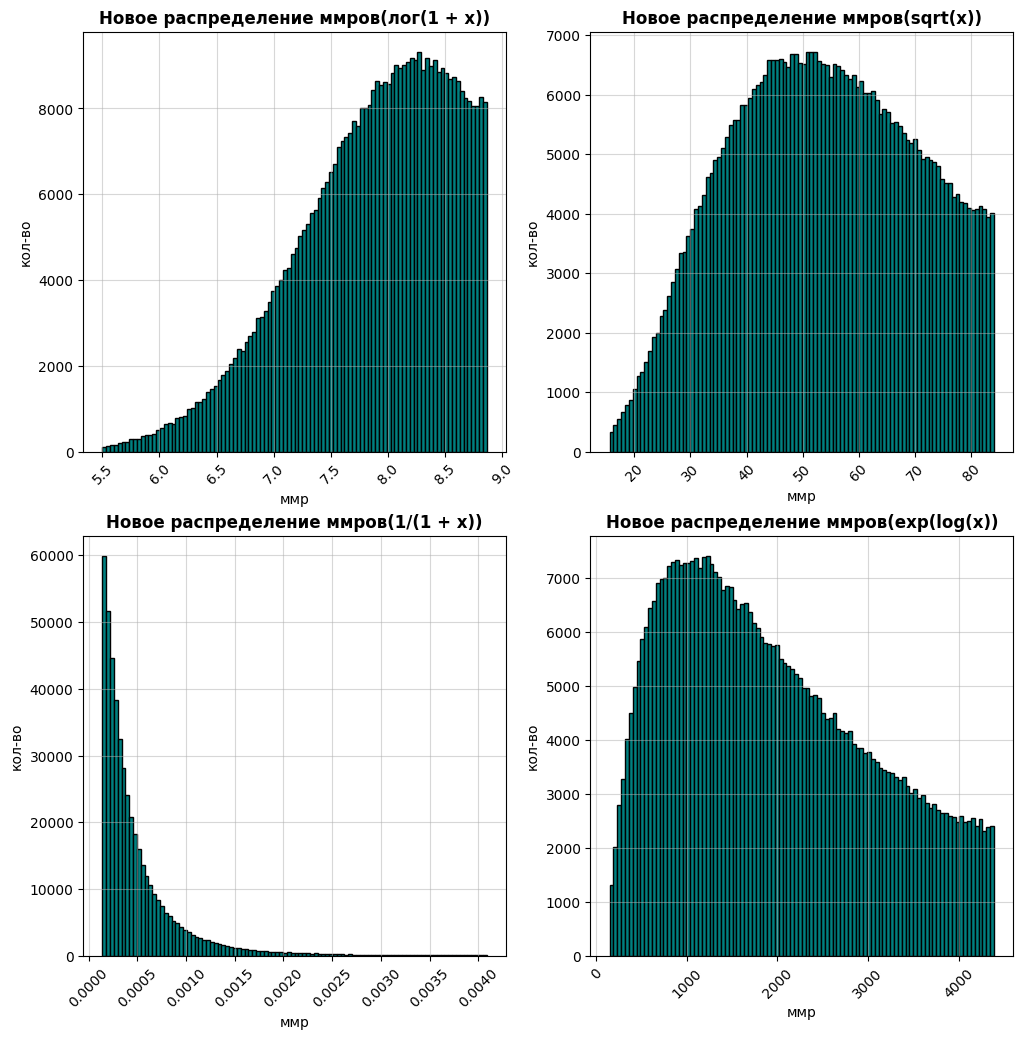

In [25]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

fig, ax = plt.subplots(2, 2, figsize=(12, 12))

for i in range(4):
    q = i//2
    w = i%2
    ax[q][w].set_xlabel("ммр")
    ax[q][w].set_ylabel("кол-во")
    ax[q][w].grid(alpha = 0.5)
    ax[q][w].tick_params(axis='x', rotation=45)

ax[0][0].hist(np.log1p(matches_df_train_enc1['avg_mmr']), bins = 100, edgecolor='black', color='teal')
ax[0][0].set_title("Новое распределение ммров(лог(1 + х))", fontweight='bold')


ax[0][1].hist(np.sqrt(matches_df_train_enc1['avg_mmr']), bins = 100, edgecolor='black', color='teal')
ax[0][1].set_title("Новое распределение ммров(sqrt(х))", fontweight='bold')

ax[1][0].hist(1 / (1 + matches_df_train_enc1['avg_mmr']), bins = 100, edgecolor='black', color='teal')
ax[1][0].set_title("Новое распределение ммров(1/(1 + х))", fontweight='bold')

ax[1][1].hist(np.exp(np.log(matches_df_train_enc1['avg_mmr'] / np.log(5))), bins = 100, edgecolor='black', color='teal')
ax[1][1].set_title("Новое распределение ммров(exp(log(х))", fontweight='bold')




plt.show()

In [26]:
# Больше всего понравился корень.
matches_df_train_enc2 = matches_df_train_enc1.copy()
matches_df_test_enc2 = matches_df_test_enc1.copy()

matches_df_train_enc2['avg_mmr'] = np.sqrt(matches_df_train_enc1['avg_mmr'])
matches_df_test_enc2['avg_mmr'] = np.sqrt(matches_df_test_enc1['avg_mmr'])


Мы как-то раньше не обращали внимание, но шестое чувство подсказывает, что в ммрах есть пропуски. Выкинуть их не получится, потому что на тесте они тоже есть, поэтому выход один — чем-то заполнять. 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

А пропуски у нас есть, потому что не все игры рейтинговые, там информацию по ммру собрать не удастся

В категориальных признаках пропуски не так важны для линрега, их можно закодировать специальной категорией. В числовых проигнорировать их не получится

В любом случае, лучше дополнительно добавить признак-флаг `mmr_missing`, который говорит, что пропуск там на самом деле есть. <font color="#cb9255">**Можете**</font> замерить его влияние, если есть желание, вдруг мы советуем полную дичь и там Джини 0.9?

</div>

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** нормально ли в данном случае заполнить пропуски нулём? А чем тогда, если нет?

**Ответ:**
На самом деле, так как мы вводим дополнительный столбец, то можно заполнить нулем, чтобы ммр не влиял на нерейтиноговые матчи.
</div>

In [27]:


matches_df_train_enc2['mmr_missing'] = matches_df_train_enc2['avg_mmr'].isna().astype(int)
matches_df_train_enc2['avg_mmr'] = matches_df_train_enc2['avg_mmr'].fillna(0)
matches_df_test_enc2['mmr_missing'] = matches_df_test_enc2['avg_mmr'].isna().astype(int)
matches_df_test_enc2['avg_mmr'] = matches_df_test_enc2['avg_mmr'].fillna(0)


matches_df_train_enc1['mmr_missing'] = matches_df_train_enc1['avg_mmr'].isna().astype(int)
matches_df_train_enc1['avg_mmr'] = matches_df_train_enc1['avg_mmr'].fillna(0)
matches_df_test_enc1['mmr_missing'] = matches_df_test_enc1['avg_mmr'].isna().astype(int)
matches_df_test_enc1['avg_mmr'] = matches_df_test_enc1['avg_mmr'].fillna(0)

Момент истины. Обучите две новые модели: к оптимальному набору фичей из предыдущего пункта добавьте в одном случае фичу без преобразования, а в другом — после преобразования. Зацените эффект на трейне и на валидации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Помните, что как бы ни было прекрасно и информативно преобразование в вашей голове, ключевое это перформанс на отложенной выборке \
В жизни каждого дата-сайентиста бывает такое, что фича, которая ну должна быть клёвой, <i>математически</i>, на практике оказывается той ещё жижей, и такое, увы, тоже нужно отслеживать

</div>

In [28]:
matches_df_train_enc1.columns

Index(['match_id', 'date', 'region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'game_mode', 'avg_mmr', 'day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays',
       'radiant_win', 'mmr_missing'],
      dtype='object')

In [29]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.preprocessing import StandardScaler

X_old = matches_df_train_enc1.drop(target, axis=1)
y_old = matches_df_train_enc1[target]
X_without = X_old[['region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'avg_mmr', 'mmr_missing', 'day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays']]

cv_results = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

def scaler_mmr(X_train, X_test):
    scaler2 = StandardScaler()

    X_train_scaled = X_train.copy()
    X_test_scaled = X_test.copy()
    
    scaler2.fit(X_train['avg_mmr'].values.reshape(-1, 1))
    
    X_train_scaled['avg_mmr'] = scaler2.transform(X_train['avg_mmr'].values.reshape(-1, 1))
    X_test_scaled['avg_mmr'] = scaler2.transform(X_test['avg_mmr'].values.reshape(-1, 1))

    return X_train_scaled, X_test_scaled
    

    

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_without)):
    print(f"ФОЛД {fold + 1}")
    
    X_train, X_val = X_without.iloc[train_idx], X_without.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )

    X_train, X_val = scaler_mmr(X_train, X_val)
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted')
    recall = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_pred_proba)


    cv_results['fold'].append(fold + 1)
    cv_results['accuracy'].append(accuracy)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1'].append(f1)
    cv_results['roc_auc'].append(roc_auc)
    
print("результаты, старый ммр, фичи: дата+регион+ммр:")

results_df = pd.DataFrame(cv_results)
print(results_df.round(4))

print(f"\nСредние значения:")
print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}")
print(f"  Precision: {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
print(f"  F1-score:  {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}")
print(f"  ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}")

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты, старый ммр, фичи: дата+регион+ммр:
   fold  accuracy  precision  recall      f1  roc_auc
0     1    0.5504     0.5531  0.5504  0.5507   0.5714
1     2    0.5530     0.5535  0.5530  0.5530   0.5736
2     3    0.5548     0.5539  0.5548  0.5540   0.5735
3     4    0.5521     0.5523  0.5521  0.5519   0.5710
4     5    0.5535     0.5531  0.5535  0.5531   0.5725

Средние значения:
  Accuracy:  0.5528 +/- 0.0015
  Precision: 0.5532 +/- 0.0005
  Recall:    0.5528 +/- 0.0015
  F1-score:  0.5525 +/- 0.0011
  ROC-AUC:   0.5724 +/- 0.0010


In [30]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_new = matches_df_train_enc2.drop(target, axis=1)
y_new = matches_df_train_enc2[target]
X_with_new = X_new[['region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'avg_mmr', 'mmr_missing',  'day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays']]

cv_results = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': []
}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_with_new)):
    print(f"ФОЛД {fold + 1}")
    
    X_train, X_val = X_with_new.iloc[train_idx], X_with_new.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    X_train, X_val = scaler_mmr(X_train, X_val)

    model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted')
    recall = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_pred_proba)


    cv_results['fold'].append(fold + 1)
    cv_results['accuracy'].append(accuracy)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1'].append(f1)
    cv_results['roc_auc'].append(roc_auc)
    
print("результаты, новый ммр, фичи: дата+регион+ммр:")

results_df = pd.DataFrame(cv_results)
print(results_df.round(4))

print(f"\nСредние значения:")
print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}")
print(f"  Precision: {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
print(f"  F1-score:  {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}")
print(f"  ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}")

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты, новый ммр, фичи: дата+регион+ммр:
   fold  accuracy  precision  recall      f1  roc_auc
0     1    0.5515     0.5529  0.5515  0.5519   0.5723
1     2    0.5538     0.5538  0.5538  0.5538   0.5743
2     3    0.5538     0.5536  0.5538  0.5537   0.5739
3     4    0.5521     0.5525  0.5521  0.5514   0.5714
4     5    0.5539     0.5531  0.5539  0.5527   0.5732

Средние значения:
  Accuracy:  0.5530 +/- 0.0010
  Precision: 0.5532 +/- 0.0005
  Recall:    0.5530 +/- 0.0010
  F1-score:  0.5527 +/- 0.0010
  ROC-AUC:   0.5730 +/- 0.0010


С корнем даже чуть лучше работает.

In [31]:
final_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight='balanced'
)

X_with_new = X_new[['region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'avg_mmr', 'mmr_missing', 'day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays']]

X_test = matches_df_test_enc2[['region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'avg_mmr', 'mmr_missing', 'day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays']]

X_with_new_sc, X_test_sc = scaler_mmr(X_with_new, X_test)

final_model.fit(X_with_new_sc, y_new)

test_probabilities = final_model.predict_proba(X_test_sc)


test_probabilities_class_1 = test_probabilities[:, 1]

results_df = pd.DataFrame({
    'ID': matches_df_test_enc2['match_id'],
    'Value': test_probabilities_class_1,
})



results_df.to_csv('probnie_resi.csv', index=False)

### **Часть 2. Векторы** (1.5 балла) <img align="center" height=28 width=28 src="https://static.wikia.nocookie.net/dota2_gamepedia/images/1/17/Emoticon_sick.gif/revision/latest?cb=20180504011850">


#### **Задание 2.1. Большая чистка** (0.75 балла)

Пока что мы никак не использовали информацию про героев, а ведь от них напрямую зависит исход матча, их больше 100 штук и все они разные: кто-то сильнее, кто-то слабее, а кто-то красивее :3. Только в данные кто-то нагадил, придётся убирать! Тут придётся ещё разочек освежить `pandas`/`polars`

Датасеты, которые нас интересуют теперь — `player_df.csv` и `Constants.Heroes.csv`. Там есть и данные на трейне, и на тесте, мы их обязательно приджойним, но потом.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Данные, как и стойло, необходимо чистить. Ранее нам везло и в целом каких-то извращений мы не наблюдали, да и тут сходу не увидим. Т.н. *"выбросы"* это, во-первых, тема отдельного холивара, а во-вторых история про доменное несоответствие, матстат такое не найдёт, но на то у нас есть мозг, верно?

Под доменом имеется в виду контекст, в котором создаются ваши данные, и процессы которого ваши данные описывают (в нашем случае — то, как устроена игра и баланс в ней). Тогда выброс — это то, что в контекст не вписывается, даже если ошибки там нет. Про это весь пункт

</div>

Первое, что нужно отсмотреть - главные ключи. Начнём с игроков. Повертите `account_id`, вас должны смутить как минимум два айдишника.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Не все игроки делают свой профиль публичным, их айди в таком случае будет анонимизирован

Небольшая часть данных собрана некорректно, айди таких игроков тоже помечен особенным значением

</div>

In [32]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

player_df = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/player_df.csv')
heroes_df = pd.read_csv('/kaggle/input/competitions/dota-2-hse-ml-1-course-competition-2026/Constants.Heroes.csv')



print("игроки", player_df.memory_usage(deep=True).sum()/(1024*1024), "мб", player_df.shape)
print("герои", heroes_df.memory_usage(deep=True).sum()/(1024*1024), "мб", heroes_df.shape)


игроки 817.1963996887207 мб (7650825, 14)
герои 0.08921241760253906 мб (126, 34)


In [33]:
print(player_df.isna().sum())

player_slot          0
account_id           0
hero_id              0
kills           607494
deaths          607494
assists         607494
gold            607494
last_hits       607494
denies          607494
gold_per_min    607494
xp_per_min      607494
hero_damage     607494
tower_damage    607494
match_id             0
dtype: int64


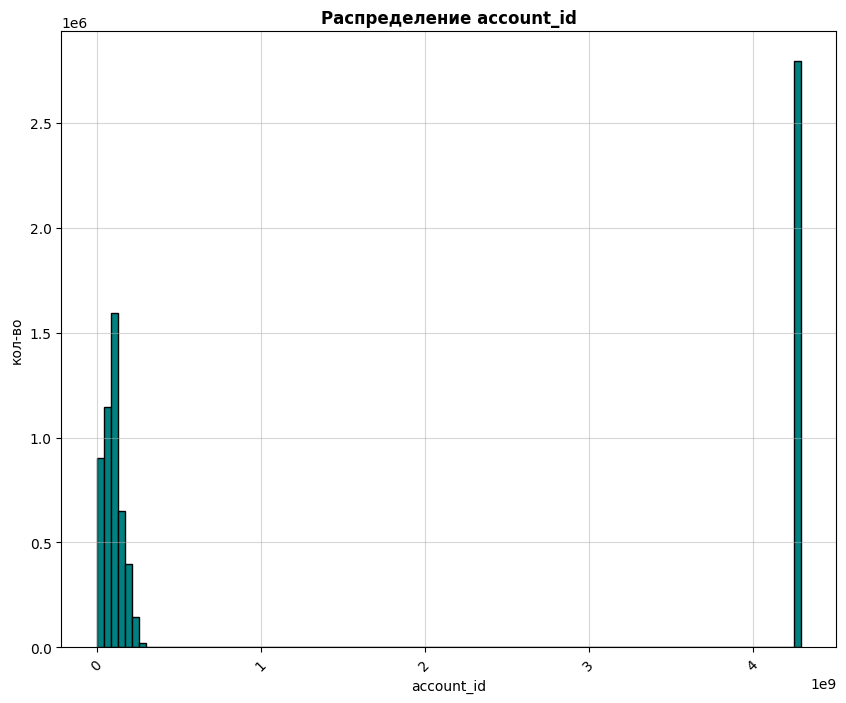

In [34]:
fig, ax = plt.subplots(figsize=(10, 8))
ax.hist(player_df['account_id'], bins = 100, edgecolor='black', color='teal')

ax.set_title("Распределение account_id", fontweight='bold')
ax.set_xlabel("account_id")
ax.set_ylabel("кол-во")
ax.grid(alpha = 0.5)
ax.tick_params(axis='x', rotation=45)



plt.show()

In [35]:
print(player_df['account_id'].min())
print(player_df['account_id'].max())

-1
4294967295


27267
2795673


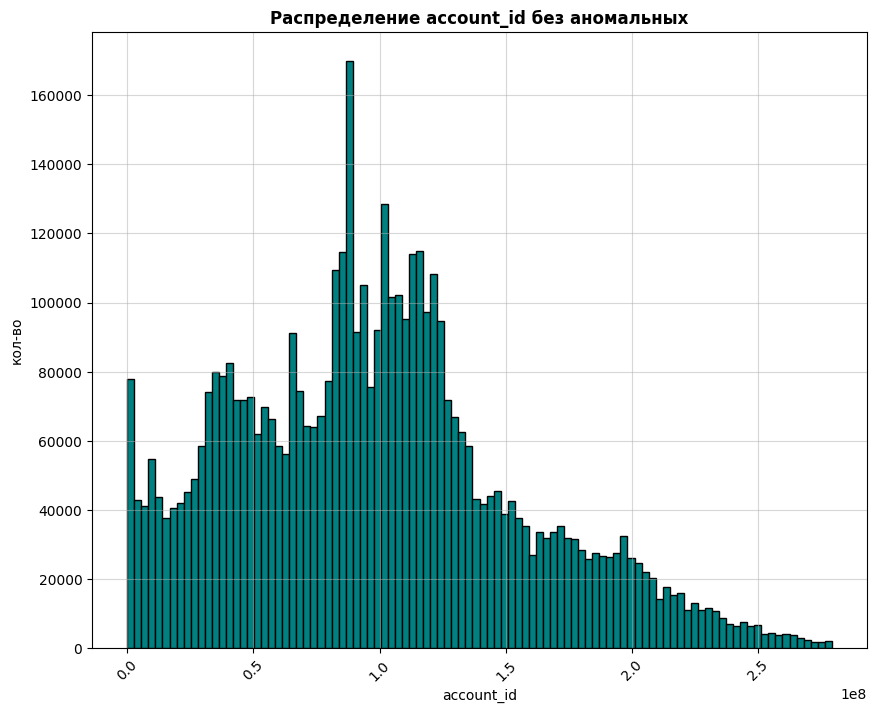

In [36]:
print((player_df['account_id'] == player_df['account_id'].min()).sum())
print((player_df['account_id'] == player_df['account_id'].max()).sum())
player_without_df = player_df[(player_df['account_id'] != player_df['account_id'].max())]
player_without_df = player_without_df[(player_without_df['account_id'] != player_without_df['account_id'].min())]


fig, ax = plt.subplots(figsize=(10, 8))
ax.hist(player_without_df['account_id'], bins = 100, edgecolor='black', color='teal')

ax.set_title("Распределение account_id без аномальных", fontweight='bold')
ax.set_xlabel("account_id")
ax.set_ylabel("кол-во")
ax.grid(alpha = 0.5)
ax.tick_params(axis='x', rotation=45)



plt.show()

In [37]:

player_anomal_min_df = player_df[(player_df['account_id'] == player_df['account_id'].min())]
player_anomal_max_df = player_df[(player_df['account_id'] == player_df['account_id'].max())]

player_anomal_min_df.describe()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
count,27267.000000,27267.0,27267.000000,25189.000000,25189.000000,25189.000000,25189.000000,25189.000000,25189.000000,25189.000000,25189.000000,25189.000000,25189.000000,27267.000000
mean,65.097847,-1.0,34.020868,3.547580,10.983008,6.258168,698.355076,42.726071,6.656517,279.678471,337.465481,6261.893763,213.365080,351594.744490
std,64.008339,0.0,25.631358,3.612802,4.325897,4.835569,1075.045429,36.231098,7.667209,113.733487,135.627152,4319.054534,489.527878,219718.280896
min,0.000000,-1.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,13.000000,0.000000,0.000000,0.000000,324.000000
25%,2.000000,-1.0,16.000000,1.000000,8.000000,3.000000,141.000000,18.000000,0.000000,211.000000,239.000000,3374.000000,0.000000,159360.000000
50%,4.000000,-1.0,29.000000,3.000000,11.000000,5.000000,394.000000,33.000000,5.000000,264.000000,319.000000,5238.000000,48.000000,333756.000000
75%,130.000000,-1.0,47.000000,5.000000,13.000000,9.000000,810.000000,55.000000,10.000000,328.000000,413.000000,7992.000000,217.000000,535458.500000
max,132.000000,-1.0,111.000000,45.000000,78.000000,37.000000,26923.000000,483.000000,72.000000,2500.000000,2071.000000,49825.000000,9278.000000,767637.000000


In [38]:
player_anomal_max_df.describe()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
count,2.795673e+06,2.795673e+06,2.795673e+06,2.573166e+06,2.573166e+06,2.573166e+06,2.573166e+06,2.573166e+06,2.573166e+06,2.573166e+06,2.573166e+06,2.573166e+06,2.573166e+06,2.795673e+06
mean,6.502804e+01,4.294967e+09,4.804272e+01,7.236213e+00,7.969618e+00,1.102632e+01,1.723033e+03,1.194441e+02,3.916878e+00,3.858612e+02,4.442594e+02,1.164021e+04,1.118077e+03,3.790331e+05
std,6.400842e+01,2.498579e-01,3.248728e+01,5.582420e+00,3.989099e+00,6.463574e+00,1.643431e+03,8.748326e+01,4.955931e+00,1.257583e+02,1.460989e+02,6.708658e+03,1.552053e+03,2.231770e+05
min,0.000000e+00,4.294967e+09,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.300000e+01,0.000000e+00,0.000000e+00,0.000000e+00,8.000000e+00
25%,2.000000e+00,4.294967e+09,2.000000e+01,3.000000e+00,5.000000e+00,6.000000e+00,5.220000e+02,5.500000e+01,1.000000e+00,2.970000e+02,3.430000e+02,6.786000e+03,9.400000e+01,1.836480e+05
50%,4.000000e+00,4.294967e+09,4.200000e+01,6.000000e+00,8.000000e+00,1.000000e+01,1.220000e+03,9.900000e+01,2.000000e+00,3.720000e+02,4.410000e+02,1.044200e+04,4.930000e+02,3.759580e+05
75%,1.300000e+02,4.294967e+09,7.500000e+01,1.000000e+01,1.100000e+01,1.500000e+01,2.470000e+03,1.620000e+02,5.000000e+00,4.610000e+02,5.420000e+02,1.524800e+04,1.487000e+03,5.741640e+05
max,1.320000e+02,4.294967e+09,1.120000e+02,7.700000e+01,7.500000e+01,7.400000e+01,5.950200e+04,2.000000e+03,1.030000e+02,2.500000e+03,2.500000e+03,8.221400e+04,2.178900e+04,7.678210e+05


In [39]:
player_without_df.describe()

,player_slot,account_id,hero_id,kills,deaths,assists,gold,last_hits,denies,gold_per_min,xp_per_min,hero_damage,tower_damage,match_id
count,4.827885e+06,4.827885e+06,4.827885e+06,4.444976e+06,4.444976e+06,4.444976e+06,4.444976e+06,4.444976e+06,4.444976e+06,4.444976e+06,4.444976e+06,4.444976e+06,4.444976e+06,4.827885e+06
mean,6.656502e+01,9.865961e+07,5.022998e+01,7.364364e+00,7.414681e+00,1.138074e+01,1.870819e+03,1.312015e+02,5.337508e+00,4.015835e+02,4.543523e+02,1.187930e+04,1.278895e+03,3.869914e+05
std,6.401309e+01,5.599874e+07,3.308709e+01,5.659357e+00,3.913697e+00,6.558705e+00,1.762731e+03,1.011834e+02,6.090028e+00,1.362355e+02,1.500948e+02,6.952475e+03,1.765527e+03,2.207140e+05
min,0.000000e+00,1.110000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.000000e+00,5.622894e+07,2.100000e+01,3.000000e+00,5.000000e+00,7.000000e+00,5.860000e+02,5.600000e+01,1.000000e+00,3.040000e+02,3.480000e+02,6.796000e+03,1.140000e+02,1.974900e+05
50%,1.280000e+02,9.518958e+07,4.600000e+01,6.000000e+00,7.000000e+00,1.100000e+01,1.338000e+03,1.080000e+02,3.000000e+00,3.840000e+02,4.500000e+02,1.056400e+04,5.510000e+02,3.886430e+05
75%,1.300000e+02,1.290413e+08,7.900000e+01,1.000000e+01,1.000000e+01,1.500000e+01,2.674000e+03,1.800000e+02,7.000000e+00,4.850000e+02,5.550000e+02,1.562600e+04,1.696000e+03,5.771270e+05
max,1.320000e+02,2.790946e+08,1.120000e+02,1.280000e+02,7.100000e+01,1.280000e+02,6.540500e+04,2.000000e+03,2.230000e+02,2.500000e+03,2.500000e+03,1.000000e+05,3.247700e+04,7.678210e+05


<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** можем ли мы себе позволить выкинуть матчи с какими-либо подозрительными айди без большого ущерба данным?

**Ответ:**
К данным с максимальным айди у меня вопросов особо нет, там распределение данных примерно такое же как и на остальных.

А вот с айди -1 как то странно. И киллов сильно меньше, и смертей больше, и дамаг по башне меньше.
К тому же их не очень много, поэтому эти айдишники удалю.

Предположу, что -1 это "дружеские" катки, а макс айди это просто челы скрыли его.
</div>

In [40]:
player_ok_df = player_df[(player_df['account_id'] != player_df['account_id'].min())]

print(100 - 100 * player_ok_df.shape[0] / player_df.shape[0])

0.35639293801648364


Удалили 0.35% данных, норм

Следующий логический шаг — одинаковых героев быть в одном матче не должно.  

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

В кастомных, т.е. не основных режимах игры, это может быть не так, но нас они не интересуют

</div>

Найдите, есть ли игры, в которых это по какой-то причине не так. Если таких матчей не слишком много, избавьтесь от них

In [41]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )
player_ok_df.columns


Index(['player_slot', 'account_id', 'hero_id', 'kills', 'deaths', 'assists',
       'gold', 'last_hits', 'denies', 'gold_per_min', 'xp_per_min',
       'hero_damage', 'tower_damage', 'match_id'],
      dtype='object')

In [42]:
player_ok_df = player_ok_df.drop(['kills', 'deaths', 'assists',
       'gold', 'last_hits', 'denies', 'gold_per_min', 'xp_per_min',
       'hero_damage', 'tower_damage'] , axis = 1)

In [43]:
nonduplicate_mask = (
    player_ok_df.groupby('match_id')['hero_id'].transform('nunique') == 
    player_ok_df.groupby('match_id')['hero_id'].transform('size')
)

player_ok_clean = player_ok_df[nonduplicate_mask]

print(f"Было: {len(player_ok_df)}")
print(f"Стало: {len(player_ok_clean)}")
print(f"Удалено строк с дубликатами: {len(player_ok_df) - len(player_ok_clean)}")

Было: 7623558
Стало: 7617237
Удалено строк с дубликатами: 6321


Вы могли заметить героя-импостера под индексом 0. Если вы посмотрите в `Constants.Heroes.csv`, то его там не найдёте, потому что это тоже ошибка.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Скорее всего это те, кто не успел выбрать героя, игра могла просто не начаться

Вряд ли у нас получится заполнить пропуски чем-то адекватным — они зависят от игрока и героя, переменных много. Попробовать можно, но точно не в базовой части

</div>

Финальным аккордом:

- посмотрите, что за игроки играли на герое с `hero_id=0`, и выкиньте такие матчи вместе со всеми пропусками
- найдите игроков, которые в одном матче играли одновременно и за команду сил Тьмы (слоты `{128, ..., 132}`), и за команду сил Света (слоты `{0, ..., 4}`), не являясь подозрительными айди из пункта выше, уберите их
- отфильтруйте `player_df`, оставьте только те матчи, которые есть в наших выборках
- проверьте, что в каждом матче ровно 5 игроков за Свет и ровно 5 за Тьму

Можно в любом порядке, но эти вещи нужно проверить, они поломают следующий пункт

In [44]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

mask1 = (
    player_ok_clean.groupby('match_id')['hero_id'].transform('min') != 0
)

player_ok_clean = player_ok_clean[mask1]
player_ok_clean.shape

(7609516, 4)

In [45]:

player_ok_clean = player_ok_clean.dropna()
player_ok_clean.shape

(7609516, 4)

In [46]:
# dfop = player_ok_clean.copy()
# dfop['is_radiant'] = dfop['player_slot'].between(0, 4)
# dfop['is_dire'] = dfop['player_slot'].between(128, 132)

# player_stats = dfop.groupby(['match_id', 'account_id']).agg({    'is_radiant': 'max',    'is_dire': 'max'
# }).reset_index()


# two_sides = player_stats[(player_stats['is_radiant']) & (player_stats['is_dire'])]
# suspicious_accounts = set(two_sides['match_id'])
# player_ok_clean = player_ok_clean[~player_ok_clean['match_id'].isin(suspicious_accounts)]

# player_ok_clean.shape

# Кароче я не знаю почему, но вот проверка на то, что чел не играет одновременно
# за обе команды и что ровно по 5 челов за силы света и тьмы
# дало буст Джини с 0.20 до 0.31 на кросс валидации и с 0.16 до 0.277 на тесте в сореве
# так что не будем выполнять эти чистки.

In [47]:
# df_check = player_ok_clean.copy()


# df_check['team'] = df_check['player_slot'].apply(
#     lambda x: 'radiant' if 0 <= x <= 4 else 'dire' if 128 <= x <= 132 else 'unknown'
# )

# team_counts = df_check.groupby(['match_id', 'team']).size().unstack(fill_value=0)

# valid_matches_mask = (team_counts['radiant'] == 5) & (team_counts['dire'] == 5)
# valid_match_ids = team_counts[valid_matches_mask].index

# player_ok_clean = player_ok_clean[player_ok_clean['match_id'].isin(valid_match_ids)]

# player_ok_clean.shape

# Кароче я не знаю почему, но вот проверка на то, что чел не играет одновременно
# за обе команды и что ровно по 5 челов за силы света и тьмы
# дало буст Джини с 0.20 до 0.31 на кросс валидации и с 0.16 до 0.277 на тесте в сореве
# так что не будем выполнять эти чистки.

In [48]:
all_match_ids = set(matches_df_train_enc2['match_id'].unique()) | set(matches_df_test_enc2['match_id'].unique())

print(f"Всего валидных match_id: {len(all_match_ids)}")

player_ok_clean_filtered = player_ok_clean[
    player_ok_clean['match_id'].isin(all_match_ids)
]

print(player_ok_clean_filtered.shape, player_ok_clean.shape )

Всего валидных match_id: 700838
(6971761, 4) (7609516, 4)


In [49]:
player_ok_clean_filtered.describe()

,player_slot,account_id,hero_id,match_id
count,6.971761e+06,6.971761e+06,6.971761e+06,6.971761e+06
mean,6.600367e+01,1.638734e+09,4.945798e+01,3.839292e+05
std,6.401563e+01,2.023095e+09,3.287995e+01,2.216839e+05
min,0.000000e+00,1.110000e+02,1.000000e+00,1.000000e+00
25%,2.000000e+00,8.349895e+07,2.100000e+01,1.919780e+05
50%,1.280000e+02,1.378667e+08,4.400000e+01,3.840370e+05
75%,1.300000e+02,4.294967e+09,7.700000e+01,5.758500e+05
max,1.320000e+02,4.294967e+09,1.120000e+02,7.678210e+05


#### **Задание 2.2. Энкодер героев** (0.75 балла)

А зачем мы вообще этим занимаемся? Вопрос хороший. План был в том, чтобы закодировать комбинации героев, которые участвуют в матче. Это чуть более сложный признак, чем обычный трансформ, тут придется поколдовать.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея в том, что какие-то комбинации героев эффективнее других. Если понять, что в матче за персонажи, можно сразу же прикинуть шансы на победу одной из сторон

</div>

Ваша задача - закодировать каждый матч вектором вида:

| match_id | hero_1 | hero_2 | hero_3 | ... | hero_n |
| --- | --- | --- | --- | --- | --- |
| 228 | 1 | 0 | -1 | ... | 0 |

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Потом <font color="#cb9255">**можно**</font> бахнуть One-Hot и разбить героев на две команды, если не боитесь переобучения. Вещь необязательная

</div>

Потребуются таблицы `player_df.csv` и `matches_df_*.csv`. Для удобства может пригодиться `Constants.Heroes.csv` (индексы оттуда и в `player_df` верные, по ним можно джойнить, но они идут не по порядку, не смотрите на пандасовский айди).

Хочется видеть либо функцию, либо в идеале класс, который вертит фичами вот так:

Каждый элемент в векторе матча `(hero_1, ..., hero_n)` принимает значение 1, если герой был в команде сил Света (слоты `{0, ..., 4}`), и -1, если в команде сил Тьмы (слоты `{128, ..., 132}`). 

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Класс нужен, поскольку при неаккуратной реализации есть риск не влезть в память при трансформе целого датасета. Главное, чтобы была функция, а там можно применять её на батч. 

Либо же <font color="#cb9255">**можете**</font> преисполниться спарс матрицами, которые экономно (не) хранят миллионы нулей. Вещь несложная и полезная

</div>

Реализуйте то, что написано

In [50]:
from scipy.sparse import csr_array  # вам может понравиться




class HeroesEncoder:

    def fit(self, X, y=None):
        pass

    def transform(self, X, y=None):
        df = X.copy()


        df['side_indicator'] = 0
        df.loc[df['player_slot'].between(0, 4), 'side_indicator'] = 1  
        df.loc[df['player_slot'].between(128, 132), 'side_indicator'] = -1 
        
        hero_matrix = df.pivot_table(
            index='match_id',
            columns='hero_id',
            values='side_indicator',
            fill_value=0,
            aggfunc='first'
        )
    

        hero_matrix.columns = hero_matrix.columns.astype(str)
        hero_matrix = hero_matrix.drop('1', axis = 1)
        
        print(f"Размерность матрицы: {hero_matrix.shape}")
        return hero_matrix



Осталось лишь самое сладкое — проверить фичу в деле. Обучите две модели: одну со всеми фичами, что мы накрутили, и одну только с фичами героев, покажите качество

In [51]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

enc = HeroesEncoder()
matr = enc.transform(X = player_ok_clean_filtered)

matr

Размерность матрицы: (699678, 109)


hero_id,2,3,4,5,6,7,8,9,10,11,...,102,103,104,105,106,107,109,110,111,112
match_id,,,,,,,,,,,,,,,,,,,,,
1,0,0,0,-1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,-1,0,0,...,0,0,0,0,1,0,0,0,0,0
3,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,1,0,-1,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767816,-1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
767817,0,0,0,0,-1,0,0,0,0,0,...,0,1,0,-1,0,0,0,0,0,0
767818,0,0,-1,0,0,0,0,0,0,0,...,0,0,0,-1,0,0,-1,1,0,0


In [52]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

X_opa = matches_df_train_enc2.drop(target, axis=1)
y_opa = matches_df_train_enc2.set_index('match_id')[target]
X_nado = X_opa[['match_id', 'region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'avg_mmr', 'mmr_missing',
        'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0']]

X_t = ((X_nado)
    .set_index('match_id')
    .join(matr, how='left')
    .fillna(0)
)

y_t = y_opa.loc[X_t.index]

cv_results = {
    'fold': [],
    'accuracy': [],
    'precision': [],
    'recall': [],
    'f1': [],
    'roc_auc': [],
    'gini': []
}

for fold, (train_idx, val_idx) in enumerate(tscv.split(X_t)):
    print(f"ФОЛД {fold + 1}")
    
    X_train, X_val = X_t.iloc[train_idx], X_t.iloc[val_idx]
    y_train, y_val = y_t.iloc[train_idx], y_t.iloc[val_idx]

    X_train, X_val = scaler_mmr(X_train, X_val)

    model = LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight='balanced'
    )
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_val)
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    
    accuracy = accuracy_score(y_val, y_pred)
    precision = precision_score(y_val, y_pred, average='weighted')
    recall = recall_score(y_val, y_pred, average='weighted')
    f1 = f1_score(y_val, y_pred, average='weighted')
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    gini = abs(2*roc_auc - 1)


    cv_results['fold'].append(fold + 1)
    cv_results['accuracy'].append(accuracy)
    cv_results['precision'].append(precision)
    cv_results['recall'].append(recall)
    cv_results['f1'].append(f1)
    cv_results['roc_auc'].append(roc_auc)
    cv_results['gini'].append(gini)
    
print("результаты, фичи: герои+дата+регион+ммр:")

results_df = pd.DataFrame(cv_results)
print(results_df.round(4))

print(f"\nСредние значения:")
print(f"  Accuracy:  {np.mean(cv_results['accuracy']):.4f} +/- {np.std(cv_results['accuracy']):.4f}")
print(f"  Precision: {np.mean(cv_results['precision']):.4f} +/- {np.std(cv_results['precision']):.4f}")
print(f"  Recall:    {np.mean(cv_results['recall']):.4f} +/- {np.std(cv_results['recall']):.4f}")
print(f"  F1-score:  {np.mean(cv_results['f1']):.4f} +/- {np.std(cv_results['f1']):.4f}")
print(f"  ROC-AUC:   {np.mean(cv_results['roc_auc']):.4f} +/- {np.std(cv_results['roc_auc']):.4f}")
print(f"  gini:      {np.mean(cv_results['gini']):.4f} +/- {np.std(cv_results['gini']):.4f}")

ФОЛД 1
ФОЛД 2
ФОЛД 3
ФОЛД 4
ФОЛД 5
результаты, фичи: герои+дата+регион+ммр:
   fold  accuracy  precision  recall      f1  roc_auc    gini
0     1    0.6132     0.6142  0.6132  0.6135   0.6586  0.3173
1     2    0.6137     0.6137  0.6137  0.6137   0.6586  0.3171
2     3    0.6107     0.6118  0.6107  0.6109   0.6559  0.3118
3     4    0.6127     0.6128  0.6127  0.6126   0.6570  0.3141
4     5    0.6143     0.6143  0.6143  0.6143   0.6579  0.3159

Средние значения:
  Accuracy:  0.6129 +/- 0.0012
  Precision: 0.6134 +/- 0.0010
  Recall:    0.6129 +/- 0.0012
  F1-score:  0.6130 +/- 0.0012
  ROC-AUC:   0.6576 +/- 0.0010
  gini:      0.3152 +/- 0.0021


Итого у вас должно получиться что-то на уровне $\text{Gini} = 0.25$ на тесте, а может даже выше

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Вы могли заметить, что прирост получится не таким значительным, как можно было ожидать, хотя признак сильный. Чем больше добавлять хороших признаков, тем лучше и лучше они объясняют данные.

Даже сложный и хороший по отдельности признак в комбинации с другими будет давать всё меньшее качество. Отчасти это объясняется мультиколлинеарностью, отчасти природой данных, некоторые из них просто слишком сложны

</div>

Получилось даже 0.277 Джини на тесте и 0.31 на валидации.

In [53]:
matches_df_train_enc2.columns

Index(['match_id', 'date', 'region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'game_mode', 'avg_mmr', 'day_1_30_12.0',
       'day_1_30_8.0', 'day_1_30_16.0', 'day_1_30_31.0', 'day_1_30_27.0',
       'day_1_30_21.0', 'day_1_30_7.0', 'day_1_30_19.0', 'day_1_30_1.0',
       'day_1_30_14.0', 'day_1_30_6.0', 'day_1_30_13.0', 'day_1_30_22.0',
       'day_1_30_25.0', 'day_1_30_20.0', 'day_1_30_26.0', 'day_1_30_18.0',
       'day_1_30_24.0', 'day_1_30_28.0', 'day_1_30_10.0', 'day_1_30_5.0',
       'day_1_30_29.0', 'day_1_30_11.0', 'day_1_30_17.0', 'day_1_30_23.0',
       'day_1_30_4.0', 'day_1_30_9.0', 'day_1_30_3.0', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0', 'russian_holidays',
       'radiant_win', 'mmr_missing'],
      dtype='object')

In [54]:
final_model = LogisticRegression(
    random_state=42,
    max_iter=10000,
    class_weight='balanced'
)

X_opa = matches_df_train_enc2.drop(target, axis=1)
y_opa = matches_df_train_enc2.set_index('match_id')[target]

priznaki = ['match_id', 'region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'avg_mmr', 'mmr_missing', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0']

X_nado = X_opa[priznaki]

matr = enc.transform(X = player_ok_clean_filtered)

X_train = ((X_nado)
    .set_index('match_id')
    .join(matr, how='left')
    .fillna(0)
)

y_train = y_opa.loc[X_train.index]


X_tes = matches_df_test_enc2[priznaki]

X_test = ((X_tes)
    .set_index('match_id')
    .join(matr, how='left')
    .fillna(0)
)


X_train_sc, X_test_sc = scaler_mmr(X_train, X_test)

final_model.fit(X_train_sc, y_train)

test_probabilities = final_model.predict_proba(X_test_sc)


test_probabilities_class_1 = test_probabilities[:, 1]

results_df = pd.DataFrame({
    'ID': matches_df_test_enc2['match_id'],
    'Value': test_probabilities_class_1,
})



results_df.to_csv('probnie_resi1.csv', index=False)

Размерность матрицы: (699678, 109)


### **Часть 3. Оптимизация для уже смешариков (1.25 балла)** <img height=28 width=28 align="center" src="https://cdn.7tv.app/emote/01H8RPMSBR000133946WK71YXM/1x.avif">

В которой студент изучает, как оптимизировать модель **по-взрослому**

#### **Задание 3.1. Optuna для самых маленьких** (0.75 балла)

Не стоит забывать, что у любой модели есть <font color="#cb9255">**гиперпараметры**</font>. Конечно, львиная доля качества будет идти от фичей, но списывать параметры со счетов не стоит. В конце концов, бывает, что с безнадёжным на первый взгляд набором признаков, оптимизированная модель покажет лучшее качество, чем базовая модель на топовых фичах, вот и посмотрим.
<a id="section"></a>

Для эффективного подбора гиперпараметров существует несколько решений, основанных на байесовской оптимизации. Одно из наиболее удобных — [optuna](https://optuna.org/), которая делает перебор гиперпараметров таким же лёгким и увлекательным занятием, как составление домашек по МО.

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Идея — смоделировать, какой набор гиперпараметров даст лучшее качество там, где перспективнее, на основе истории их подбора (подробнее на МО2)

</div>

Напишите функцию оптимизации для вашего классификатора. Можете воспользоваться шаблоном ниже, но он довольно куцый, курите документацию. Раз уж инструмент новый, начнём с чего-то простого. Подберите вот такие гиперпараметры (посмотрите на них, прежде, чем тюнить, у них разные диапазоны и разный же смысл (логарифмическая шкала — наш лучший друг, возможно даже лучше настоящих)):

1) Численный — `alpha` у `SGDClassifier` или параметр регуляризации `C` у всех остальных.
2) Категориальный — `solver` у `LogisticRegression`, `loss` у всех остальных
3) Число итераций — `max_iter`. Это не совсем гиперпараметр, но поверьте, обучать модель 100 лет вы не хотите, к тому же это вид неявной регуляризации

<div style="border-left: 5px solid #647cb8; padding: 10px 20px 1px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(95, 121, 179, 0.05);">

Раз уж все алгоритмы у нас итерационные, от того, как и по какой функции оптимизироваться, довольно важно

Способов применять оптуну вновь два. Выбор, как всегда, в ваших руках:\
<font color="#cb9255">**Первое**</font> — тестить после каждой фичи, это точнее, но можем переобучиться. <font color="#cb9255"> \
**Второе**</font> — подобрать параметры один раз, это проще, но зато быстро. У нас модель простая и перебирать там можно мало чего, пока что, во второй части параметров станет больше. \

</div>

In [55]:
import optuna


X_opa = matches_df_train_enc2.drop(target, axis=1)
y_opa = matches_df_train_enc2.set_index('match_id')[target]
X_nado = X_opa[['match_id', 'region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'avg_mmr', 'mmr_missing',
        'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0']]

X_t = ((X_nado)
    .set_index('match_id')
    .join(matr, how='left')
    .fillna(0)
)

y_t = y_opa.loc[X_t.index]

def objective(trial):
    # model parameters
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs'])

    
    if solver == 'liblinear':
        penalty = trial.suggest_categorical('penalty_liblinear', ['l1', 'l2'])
        params = {
            'C': trial.suggest_float('C', 1e-4, 1e2, log=True),
            'solver': solver,
            'penalty': penalty,
            'max_iter': trial.suggest_int('max_iter', 100, 2500, step=100),
            'random_state': 42,
            'class_weight': 'balanced'
        }
    else: 
        params = {
            'C': trial.suggest_float('C', 1e-4, 1e2, log=True),
            'solver': solver,
            'penalty': 'l2', 
            'max_iter': trial.suggest_int('max_iter', 100, 2500, step=100),
            'random_state': 42,
            'class_weight': 'balanced'
        }

    # fit
    # ...
    model = LogisticRegression(**params)

    gv = []
    for fold, (train_idx, val_idx) in enumerate(tscv.split(X_t)):
    
        
        X_train, X_val = X_t.iloc[train_idx], X_t.iloc[val_idx]
        y_train, y_val = y_t.iloc[train_idx], y_t.iloc[val_idx]
    
        X_train, X_val = scaler_mmr(X_train, X_val)
        
        model.fit(X_train, y_train)
        
        y_pred = model.predict(X_val)
        y_pred_proba = model.predict_proba(X_val)[:, 1]
    
        roc_auc = roc_auc_score(y_val, y_pred_proba)
        gini = abs(2*roc_auc - 1)
        gv.append(gini)
    
    

    # predict
    gini_valid = np.mean(gv)
    
    return gini_valid


study = optuna.create_study(direction="maximize")
# n_trials можно поставить и побольше, но пространство гиперпараметров здесь простое
study.optimize(objective, show_progress_bar=True, n_trials=30)

[I 2026-03-07 17:10:48,127] A new study created in memory with name: no-name-762dd8a5-89cb-4713-bc50-db7f3bfba178


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-03-07 17:11:14,018] Trial 0 finished with value: 0.3151975383449795 and parameters: {'solver': 'lbfgs', 'C': 2.20926090726345, 'max_iter': 600}. Best is trial 0 with value: 0.3151975383449795.
[I 2026-03-07 17:11:26,498] Trial 1 finished with value: 0.3037162579903615 and parameters: {'solver': 'lbfgs', 'C': 0.00040344290045921224, 'max_iter': 2500}. Best is trial 0 with value: 0.3151975383449795.
[I 2026-03-07 17:11:47,052] Trial 2 finished with value: 0.3151906108027248 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l2', 'C': 2.6570293885504532, 'max_iter': 1900}. Best is trial 0 with value: 0.3151975383449795.
[I 2026-03-07 17:12:07,844] Trial 3 finished with value: 0.3152090028233036 and parameters: {'solver': 'liblinear', 'penalty_liblinear': 'l2', 'C': 1.1594993829285618, 'max_iter': 1700}. Best is trial 3 with value: 0.3152090028233036.
[I 2026-03-07 17:12:28,895] Trial 4 finished with value: 0.31556646866064725 and parameters: {'solver': 'liblinear', 'pen

[I 2026-03-07 13:31:28,455] Trial 22 finished with value: 0.3156255380432462 and parameters: {'solver': 'lbfgs', 'C': 0.029743331803711446, 'max_iter': 1800}. Best is trial 22 with value: 0.3156255380432462.

#### **Задание 3.2. Немножко про интерпретацию** (0.25 балла)

В оптуне лежит целая россыпь визуализаций, как же их не пощупать? Чтобы окончательно убедить вас в ценности и важности регуляризации, выведите график важности гиперпараметров. Оценим, что реально важно, а что пшик

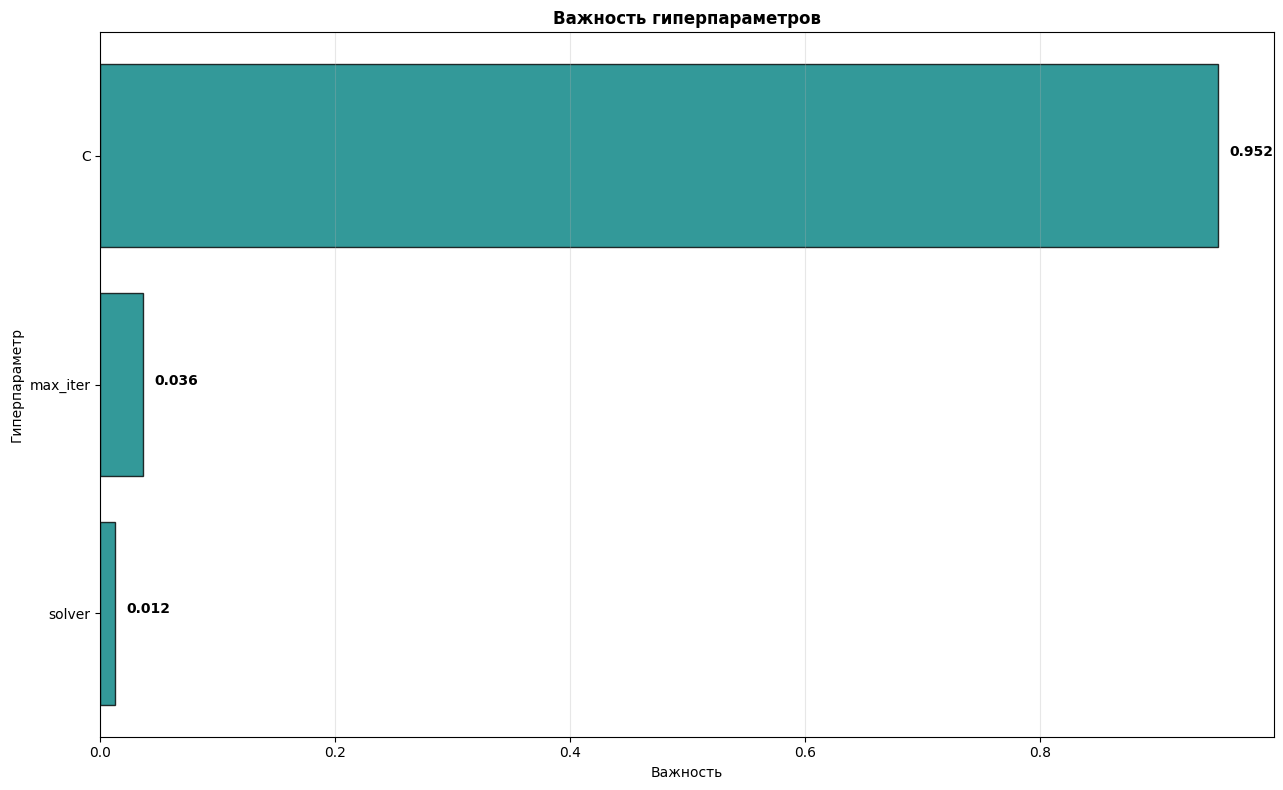

In [56]:
from optuna.importance import get_param_importances


param_importance = get_param_importances(study)


importance_df = pd.DataFrame({
    'parameter': list(param_importance.keys()),
    'importance': list(param_importance.values())
}).sort_values('importance', ascending=True)


fig, ax = plt.subplots(figsize=(13, 8))


bars = ax.barh(importance_df['parameter'], importance_df['importance'], 
               color='teal', edgecolor='black', alpha=0.8)


ax.set_title("Важность гиперпараметров", fontweight='bold')
ax.set_xlabel("Важность")
ax.set_ylabel("Гиперпараметр")
ax.grid(alpha=0.3, axis='x')

for bar, value in zip(bars, importance_df['importance']):
    ax.text(value + 0.01, bar.get_y() + bar.get_height()/2, 
            f'{value:.3f}', fontweight='bold')


ax.tick_params(axis='y')

plt.tight_layout()
plt.show()

<div style="border-left: 5px solid #c27985; padding: 10px 20px 2px; margin: 15px 0 15px 20px; max-width: 800px; background-color: rgba(255, 116, 140, 0.05);">

**Вопрос:** что вы видите и как вы прокомментируете, какие параметры важнее всего?

**Ответ:**
Самым важным парметром(аж 83%) является параметр регуляризации. Почти неважным оказался солвер. Число итераций имеет важность всего 15%.
Вывод: нужно качественно подбирать регуляризацию.

</div>

#### **Задание 3.3. Заключение** (0.25 балла)

Фуух, много конечно, ну да так уж вышло, что теперь делать, данные это всегда геморрой. Напоследок:

1. Зафиксируйте оптимальный набор гиперпараметров. 
2. Сохраните либо модель, либо pipeline для будущего себя в части advanced. 
3. Сделайте тестовый submission на [Kaggle](https://www.kaggle.com/t/6fd940fbeb1746a78031e5d0277f6105), если ещё не.

In [57]:
# (´-`）.｡oO( ... YOUR CODE HERE ... )

params = {
            'C': 0.029743331803711446,
            'solver': 'lbfgs',
            'penalty': 'l2',
            'max_iter': 1800,
            'random_state': 42,
            'class_weight': 'balanced'
        }
    
model = LogisticRegression(**params)

X_opa = matches_df_train_enc2.drop(target, axis=1)
y_opa = matches_df_train_enc2.set_index('match_id')[target]

priznaki = ['match_id', 'region_Europe West', 'region_South Africa',
       'region_Middle East', 'region_US East', 'region_Europe East',
       'region_South America', 'region_China', 'region_US West',
       'region_Australia', 'avg_mmr', 'mmr_missing', 'day_1_30_15.0',
       'day_1_30_2.0', 'weekday_6.0', 'weekday_1.0', 'weekday_5.0',
       'weekday_3.0', 'weekday_2.0', 'weekday_4.0']

X_nado = X_opa[priznaki]

matr = enc.transform(X = player_ok_clean_filtered)

X_train = ((X_nado)
    .set_index('match_id')
    .join(matr, how='left')
    .fillna(0)
)

y_train = y_opa.loc[X_train.index]


X_tes = matches_df_test_enc2[priznaki]

X_test = ((X_tes)
    .set_index('match_id')
    .join(matr, how='left')
    .fillna(0)
)


X_train_sc, X_test_sc = scaler_mmr(X_train, X_test)

model.fit(X_train_sc, y_train)

test_probabilities = model.predict_proba(X_test_sc)


test_probabilities_class_1 = test_probabilities[:, 1]

results_df = pd.DataFrame({
    'ID': matches_df_test_enc2['match_id'],
    'Value': test_probabilities_class_1,
})



results_df.to_csv('probnie_resi2.csv', index=False)

Размерность матрицы: (699678, 109)


Получилось Джини 0.27798 на тесте в соревке. 